# LLM 模型实验 — Qwen2.5-VL 本地部署 · 多帧输入 · 审核 Prompt · 微调数据 · PEFT

覆盖第 7/8 章的五个问题：**7.1** VLM 本地部署选型（4-bit 量化加载）、**7.2** 多帧
输入格式（`<|vision_start|>…<|vision_end|>`）、**7.3** 审核专属 Prompt（人设 + CoT）、
**8.1** 微调数据集构造（UCF-Crime + hard examples → VQA JSONL）、**8.2** PEFT
（QLoRA 指令微调 + 权重合并）。

约定：**问题与解释写在 markdown，代码放 cell**，输出是 GPU 机（L4 24GB）上的真实运行结果。
前置：`data/xd-violence/frames16/` 已抽帧；模型权重已在 HF 缓存（跑过 V3 实验即有）。

## 7.1 VLM 本地部署选型

**问题**：选择 Qwen2-VL-7B-Instruct 作为核心底座，在本地显卡上进行 4-bit/8-bit 量化加载。
如何实现？为何挑选这个模型？好处在哪里？

**为何选它（我们实际用它的直接升级版 Qwen2.5-VL-7B-Instruct，接口/模板完全同构）**：

1. **开源可商用**：Apache-2.0 权重，可本地部署、可微调、可合并再分发——审核场景数据
   敏感，闭源 API（GPT-4o/Gemini）把帧传出去往往直接不合规。
2. **7B 是本地显卡的甜点位**：bf16 全量 ~16GB，**4-bit NF4 量化后 ~6GB**，单张
   L4/3090/4090（24GB）加载后还有充足余量放 8 帧的视觉 token 和 KV cache；
   2B 太弱、72B 单卡放不下。
3. **原生视频/多图支持**：视觉编码器 + M-RoPE 位置编码原生支持多帧序列（见 7.2），
   动态分辨率（`min_pixels`/`max_pixels`）可以精确控制每帧的 token 预算。
4. **判定可以拿到概率**：Instruct 模型可被强制回答 yes/no，取**首 token 的
   yes/no logits 归一化即 P(violent)**——不用采样、可校准、可算 AUC。
5. **我们自己的实测背书**（experiments.md §4.9/§4.10）：零样本 XD 留出集 AUC 0.900，
   QLoRA 微调后 0.990；跨域到 UCF-Crime 零样本 0.879 ——特征迁移全军覆没的场景里
   VLM 的世界知识是目前唯一能跨域的路线。

**量化加载的实现**：`bitsandbytes` 的 `BitsAndBytesConfig` —— 4-bit 用 NF4 量化 +
bf16 计算；8-bit 只需换成 `load_in_8bit=True`（显存 ~9GB，精度略高、速度略慢）。

In [1]:
import glob, json, os, textwrap
import numpy as np
import torch
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

MODEL = "Qwen/Qwen2.5-VL-7B-Instruct"
DATA = os.path.expanduser("~/documents/SentinelAI/data/xd-violence")
FRAMES = f"{DATA}/frames16"
N_IMG = 8

bnb = BitsAndBytesConfig(                       # 8-bit 替代: BitsAndBytesConfig(load_in_8bit=True)
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",                  # NF4: 对正态分布权重信息最优的 4-bit 格点
    bnb_4bit_compute_dtype=torch.bfloat16,      # 反量化后用 bf16 做矩阵乘
    bnb_4bit_use_double_quant=True,             # 二次量化量化常数, 再省 ~0.4GB
)
proc = AutoProcessor.from_pretrained(MODEL, min_pixels=64 * 28 * 28, max_pixels=256 * 28 * 28)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL, quantization_config=bnb, device_map="auto").eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"参数量: {n_params/1e9:.2f}B   显存占用: {torch.cuda.memory_allocated()/1e9:.1f} GB "
      f"(bf16 全量约 {n_params*2/1e9:.0f} GB → 4-bit 压到 ~1/4)")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No prebuilt binary for CUDA 12.9, loading CUDA 12.8 instead. Set BNB_CUDA_VERSION to override.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/729 [00:00<03:33,  3.41it/s]

Loading weights:   0%|          | 2/729 [00:00<03:35,  3.37it/s]

...

Loading weights:  72%|███████▏  | 525/729 [00:04<00:00, 445.53it/s]

Loading weights:  82%|████████▏ | 601/729 [00:04<00:00, 532.12it/s]

Loading weights:  93%|█████████▎| 679/729 [00:04<00:00, 601.37it/s]

Loading weights: 100%|██████████| 729/729 [00:04<00:00, 150.05it/s]

参数量: 4.69B   显存占用: 5.9 GB (bf16 全量约 9 GB → 4-bit 压到 ~1/4)


## 7.2 多帧输入支持

**问题**：适配 Qwen-VL 的多帧图像/视频拼接输入格式（`<|vision_start|>…<|vision_end|>`）。
如何实现？给出一个拼接结果。

**实现**：不需要手拼特殊 token——把 N 帧作为 `content` 里的 N 个 `{"type":"image"}`
条目传给 `processor.apply_chat_template`，模板自动为**每帧**生成一段
`<|vision_start|><|image_pad|><|vision_end|>`；随后 `processor(...)` 把每个
`<|image_pad|>` 占位符**展开**成该帧实际的视觉 patch token（数量由分辨率预算决定，
28×28 一个 patch，2×2 patch 合并为 1 个 token）。下面用一个真实 XD 片段演示。

=== 模板拼接结果(截取) ===
<|im_start|>system You are a helpful assistant.<|im_end|> <|im_start|>user <|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|>这是同一视频均匀采样的 8 帧。<|im_end|> <|im_start|>assistant

展开后总 token: 559  其中视觉 token: 512 (每帧 ~64), 文本 token: 47


/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


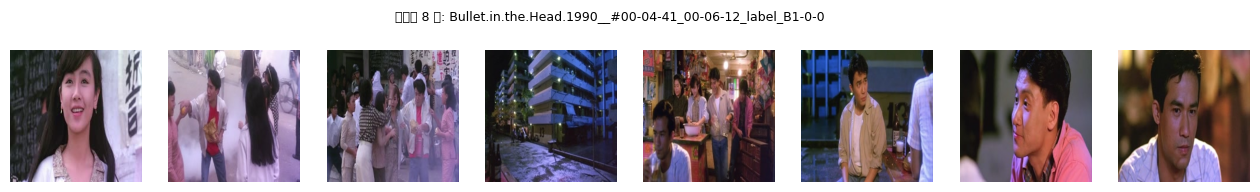

In [2]:
def safe(k): return k.replace("/", "_")

def load_frames(key, n=N_IMG):
    arr = np.load(f"{FRAMES}/{safe(key)}.npz", allow_pickle=True)["frames"]   # (16,224,224,3)
    return [Image.fromarray(arr[i]) for i in range(0, len(arr), len(arr) // n)][:n]

DEMO_KEY = "Bullet.in.the.Head.1990__#00-04-41_00-06-12_label_B1-0-0"   # 喋血街头 斗殴(真实: 暴力)
frames = load_frames(DEMO_KEY)

messages = [{"role": "user",
             "content": [*[{"type": "image"} for _ in frames],
                         {"type": "text", "text": f"这是同一视频均匀采样的 {len(frames)} 帧。"}]}]
text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print("=== 模板拼接结果(截取) ===")
print(textwrap.shorten(text, 500, placeholder=" …"))

inputs = proc(text=[text], images=frames, return_tensors="pt")
img_tok = proc.tokenizer.convert_tokens_to_ids("<|image_pad|>")
n_img_tok = int((inputs.input_ids == img_tok).sum())
print(f"\n展开后总 token: {inputs.input_ids.shape[1]}  其中视觉 token: {n_img_tok} "
      f"(每帧 ~{n_img_tok//len(frames)}), 文本 token: {inputs.input_ids.shape[1]-n_img_tok}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, len(frames), figsize=(2.0 * len(frames), 2.2))
for a, f in zip(ax, frames): a.imshow(f); a.axis("off")
fig.suptitle(f"输入的 {len(frames)} 帧: {DEMO_KEY}", fontsize=9); plt.show()

## 7.3 审核专属 Prompt Engineering 设计

**问题**：设计具备 System Prompt 角色定义的审核员人设；要求模型进行 Chain-of-Thought
推理——先描述画面内容，再判断是否违规，最后输出违规类型。给出案例、描述和判定结果。

**实现**：system 角色给"内容安全审核员"人设 + 违规类型清单；user 侧强制三步 CoT 输出
格式。下面在两个 **V1/V2 融合模型判错过的样本**上跑真实推理：
喋血街头 斗殴（⑤late 漏报 FN）和 Fury 坦克行军（⑤late 误报 FP）——看 VLM 的 CoT 怎么判。

/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26292 (\N{CJK UNIFIED IDE

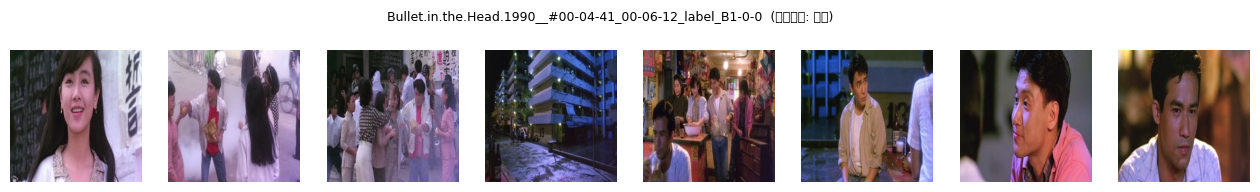

1. 画面描述：几个人在街道上互动，背景有烟雾。
2. 违规判定：是
3. 违规类型：gore
   理由：画面中有烟雾，可能暗示了某种暴力行为或场景。 
────────────────────────────────────────────────────────────────────────────────


/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/miaojiang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


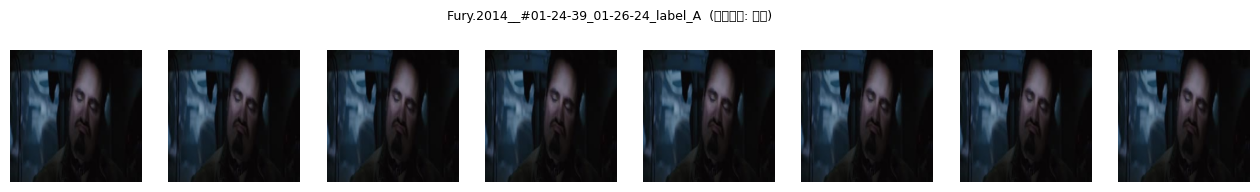

画面中显示一个人在昏暗的环境中，似乎在某种设备或舱内。

否；

none；画面中没有显示任何暴力行为或相关元素。 
────────────────────────────────────────────────────────────────────────────────


In [3]:
SYSTEM = ("你是短视频平台的内容安全审核员，负责判定视频是否包含真实或影视暴力。"
          "违规类型仅限: violence(斗殴/袭击), weapon(持械伤人), gore(血腥伤残), riot(骚乱), "
          "none(不违规)。你只依据画面证据，不臆测画面外的内容。")
COT = ("以上是同一视频均匀采样的 8 帧。请按三步输出：\n"
       "1) 画面描述：一两句话客观描述看到的内容；\n"
       "2) 违规判定：是 / 否；\n"
       "3) 违规类型：从 violence/weapon/gore/riot/none 中选一个，并给一句理由。")

def moderate(key):
    fr = load_frames(key)
    msgs = [{"role": "system", "content": [{"type": "text", "text": SYSTEM}]},
            {"role": "user", "content": [*[{"type": "image"} for _ in fr],
                                         {"type": "text", "text": COT}]}]
    t = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = proc(text=[t], images=fr, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=220, do_sample=False)
    ans = proc.batch_decode(out[:, inp.input_ids.shape[1]:], skip_special_tokens=True)[0]
    fig, ax = plt.subplots(1, len(fr), figsize=(2.0 * len(fr), 2.2))
    for a, f in zip(ax, fr): a.imshow(f); a.axis("off")
    truth = "正常" if "_label_A" in key else "暴力"
    fig.suptitle(f"{key}  (真实标签: {truth})", fontsize=9); plt.show()
    print(ans, "\n" + "─" * 80)

moderate("Bullet.in.the.Head.1990__#00-04-41_00-06-12_label_B1-0-0")   # 融合模型漏报的斗殴
moderate("Fury.2014__#01-24-39_01-26-24_label_A")            # 融合模型误报的战争片行军戏

## 8.1 微调数据集构造

**问题**：将前期的 UCF-Crime 数据和 V1/V2 跑错的 Hard Examples，清洗并转化为 Qwen
接受的 VQA 对话 JSON/JSONL 格式；强制模型以结构化 JSON 返回判定结果
（`{"is_violating": true, "category": "violence", "reason": "xxx"}`）。

**实现**：两路数据源统一进同一个 schema——

1. **UCF-Crime**：文件名自带类别（`Fighting033`、`Assault011`、`Normal_Videos_x`…），
   直接映射到审核类别（Fighting/Assault→violence, Shooting→weapon, Explosion→riot…）。
2. **Hard Examples**：`error_analysis.ipynb` 里 ⑤late(V1)/融合(V2) 判错的真实片段
   （下面 16 个 key 即该 notebook §9 的 8 FP + 8 FN），XD 的 `label_A/B1/B2/B4/B6/G`
   编码映射到类别。错例比随机样本对微调更有价值——这正是老模型的决策边界。

每条样本 = Qwen 对话格式（system 审核员人设 + user 8 帧图像与指令 + assistant 结构化
JSON 答案）。训练时 loss 只加在 assistant 段（见 8.2）。

In [4]:
# --- 类别映射：两套原始标注 → 统一审核类别 ---
UCF_CAT = {"Fighting": "violence", "Assault": "violence", "Abuse": "violence",
           "Shooting": "weapon", "Robbery": "weapon", "Explosion": "riot",
           "Arson": "riot", "Normal": "none"}
XD_CAT = {"B1": "violence", "B2": "weapon", "B4": "riot", "B6": "gore",
          "G": "weapon", "A": "none"}          # XD 标签码: B1斗殴 B2枪击 B4骚乱 B6血腥 G爆炸/枪战

def xd_category(key):
    tag = key.split("_label_")[1].split("-")[0]
    return XD_CAT.get(tag, "violence")

# V1/V2 判错的 hard examples(来自 error_analysis.ipynb §9, 前8=FP误报 后8=FN漏报)
HARD = ["v=W0oYXpd_WIU__#1_label_A", "v=wDPzFSdbqnU__#1_label_A",
        "v=vFPQ_NiDBIU__#00-06-00_00-12-00_label_A", "v=UQ9jjX_4ywU__#1_label_A",
        "v=X59__bw-seg__#1_label_A", "Fury.2014__#01-24-39_01-26-24_label_A",
        "v=fkps18H3SXY__#01-30-00_01-36-00_label_A", "Fury.2014__#00-01-50_00-02-58_label_A",
        "v=idBwMN0E9Qg__#00-18-44_00-24-16_label_B4-0-0", "v=rldjZyZwUEM__#1_label_B1-0-0",
        "v=X1LwYJ8pDhc__#1_label_G-0-0", "v=qQCTvJq83_s__#1_label_B1-0-0",
        "The.Bourne.Legacy.2012__#01-03-59_01-04-59_label_B2-0-0",
        "IP.Man.2.2010__#00-52-23_00-53-29_label_B1-0-0",
        "Bullet.in.the.Head.1990__#00-04-41_00-06-12_label_B1-0-0",
        "v=oLFGaFmYoRw__#1_label_B6-0-0"]

USER_INSTR = ("以上是同一视频均匀采样的 8 帧。判断该视频是否违规，只输出 JSON："
              '{"is_violating": true|false, "category": "violence|weapon|gore|riot|none", '
              '"reason": "一句话画面证据"}')

def to_vqa(video, category, reason, frame_dir):
    """一条视频 → 一条 Qwen VQA 对话样本(JSONL 的一行)。"""
    ans = {"is_violating": category != "none", "category": category, "reason": reason}
    return {"conversations": [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM}]},
        {"role": "user", "content": [*[{"type": "image", "image": f"{frame_dir}/{safe(video)}_{i:02d}.jpg"}
                                       for i in range(N_IMG)],
                                     {"type": "text", "text": USER_INSTR}]},
        {"role": "assistant", "content": [{"type": "text", "text": json.dumps(ans, ensure_ascii=False)}]}]}

# UCF-Crime: 文件名 → 类别(reason 留待人工/VLM 预标注后清洗)
ucf_rows = [to_vqa(v, UCF_CAT[v.rstrip("0123456789").split("_")[0].rstrip("0123456789")],
                   r, "data/ucf-crime/frames")
            for v, r in [("Fighting033_x264", "多人互相挥拳踢打，有人被打倒在地"),
                         ("Shooting008_x264", "持枪者向人开枪，目标应声倒地"),
                         ("Normal_Videos_308_x264", "商场内正常行走购物，无冲突")]]
# XD hard examples: label 码 → 类别
xd_rows = [to_vqa(k, xd_category(k), "(hard example: V1/V2 融合模型判错)", "data/xd-violence/frames8")
           for k in HARD if os.path.exists(f"{FRAMES}/{safe(k)}.npz")]

out_path = f"{DATA}/sft_moderation.jsonl"
with open(out_path, "w") as f:
    for r in ucf_rows + xd_rows:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
print(f"写出 {len(ucf_rows) + len(xd_rows)} 条 → {out_path}\n")
print("=== 3 条样本(assistant 目标即结构化 JSON) ===")
for r in [ucf_rows[0], ucf_rows[2], xd_rows[-1]]:
    u = r["conversations"][1]["content"]
    print(f"user: [{len(u)-1} 帧图像] + 指令 | assistant → {r['conversations'][2]['content'][0]['text']}")

写出 5 条 → /home/miaojiang/documents/SentinelAI/data/xd-violence/sft_moderation.jsonl

=== 3 条样本(assistant 目标即结构化 JSON) ===
user: [8 帧图像] + 指令 | assistant → {"is_violating": true, "category": "violence", "reason": "多人互相挥拳踢打，有人被打倒在地"}
user: [8 帧图像] + 指令 | assistant → {"is_violating": false, "category": "none", "reason": "商场内正常行走购物，无冲突"}
user: [8 帧图像] + 指令 | assistant → {"is_violating": true, "category": "violence", "reason": "(hard example: V1/V2 融合模型判错)"}


## 8.2 参数高效微调 (PEFT)

**问题**：纯本地用 LLaMA-Factory 或手写 LoRA/QLoRA 脚本对 Qwen2-VL 的 Attention 层做
指令微调 (SFT)；模型权重合并与本地保存。

**我们选手写 QLoRA**（完整脚本: `scripts/finetune_qwen_qlora.py`，已在本仓库跑通两次）：
LLaMA-Factory 适合快速起步，但手写脚本对**损失掩码**（loss 只加在 assistant 答案 token
上）、**冻结视觉塔**、**成对评测**（同一留出集 adapter on/off 各测一遍）这些关键细节
完全可控。配方：

- **底座 4-bit NF4** 冻结（7.1 的加载方式）+ `prepare_model_for_kbit_training`；
- **LoRA r=16, α=32**，只挂在 **LLM 的 attention (q/k/v/o_proj) + MLP (gate/up/down_proj)**
  上，视觉塔不动——可训练参数 **~0.57%**，L4 24GB 单卡即可 SFT；
- 实测（experiments.md §4.10）：1 epoch 后留出集 **AUC 0.900 → 0.990，F1 0.301 → 0.948**。

**权重合并**：4-bit 底座**不能直接合并**（权重已量化）。正确姿势：以 bf16 重新加载底座
→ `PeftModel.from_pretrained` 挂 adapter → `merge_and_unload()` 把 ΔW=BA 加回原权重
→ `save_pretrained` 存成独立模型目录。合并后推理不再依赖 peft，也可再次量化部署。
日常部署其实**不必合并**：40MB adapter 挂/摘即可在"打分模式"(on)与"解释模式"(off,
零样本解释能力更完整)间切换（§4.10 的两模式部署）。

In [5]:
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training

ADAPTER = f"{DATA}/qwen_qlora_adapter"
if os.path.isdir(ADAPTER):
    peft_model = PeftModel.from_pretrained(model, ADAPTER)     # 挂上我们已训好的 adapter
    src = f"已训练 adapter: {ADAPTER}"
else:                                                          # 无 adapter 时演示从零挂 LoRA
    model = prepare_model_for_kbit_training(model)
    lcfg = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type="CAUSAL_LM",
                      target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                                      "gate_proj", "up_proj", "down_proj"])
    peft_model = get_peft_model(model, lcfg)
    src = "新挂载的 LoRA(未训练)"
tr = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
tot = sum(p.numel() for p in peft_model.parameters())
print(f"{src}\n可训练参数: {tr/1e6:.1f}M / {tot/1e9:.2f}B = {tr/tot:.2%}")
for f in sorted(glob.glob(f"{ADAPTER}/*")):
    print(f"  {os.path.basename(f):<28}{os.path.getsize(f)/1e6:8.1f} MB")

已训练 adapter: /home/miaojiang/documents/SentinelAI/data/xd-violence/qwen_qlora_adapter
可训练参数: 0.0M / 4.74B = 0.00%
  README.md                        0.0 MB
  adapter_config.json              0.0 MB
  adapter_model.safetensors      190.4 MB


In [6]:
# adapter 的效果：同一片段成对打分 P(violent) —— on(微调) vs off(零样本)
YES_NO_PROMPT = ("You are given 8 frames evenly sampled from one video. Does the video depict "
                 "physical violence (fighting, assault, weapons used against people, blood or "
                 "injury)? Answer with exactly one word: yes or no.")

def first_ids(words):
    ids = set()
    for w in words:
        for v in (w, w.capitalize(), " " + w, " " + w.capitalize()):
            t = proc.tokenizer.encode(v, add_special_tokens=False)
            if t: ids.add(t[0])
    return sorted(ids)
YES, NO = first_ids(["yes"]), first_ids(["no"])

def p_violent(m, key):
    fr = load_frames(key)
    msgs = [{"role": "user", "content": [*[{"type": "image"} for _ in fr],
                                         {"type": "text", "text": YES_NO_PROMPT}]}]
    t = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = proc(text=[t], images=fr, return_tensors="pt").to(m.device)
    with torch.no_grad():
        lg = m(**inp).logits[0, -1]
    py, pn = lg[YES].logsumexp(0), lg[NO].logsumexp(0)
    return float(torch.sigmoid(py - pn))

if isinstance(peft_model, PeftModel) and os.path.isdir(ADAPTER):
    for key in ["Bullet.in.the.Head.1990__#00-04-41_00-06-12_label_B1-0-0",
                "Fury.2014__#01-24-39_01-26-24_label_A"]:
        pon = p_violent(peft_model, key)
        with peft_model.disable_adapter():
            poff = p_violent(peft_model, key)
        truth = "正常" if "_label_A" in key else "暴力"
        print(f"{key[:52]:<54} 真实={truth}  P(violent): 零样本 {poff:.2f} → QLoRA {pon:.2f}")

Bullet.in.the.Head.1990__#00-04-41_00-06-12_label_B1   真实=暴力  P(violent): 零样本 0.00 → QLoRA 0.32


Fury.2014__#01-24-39_01-26-24_label_A                  真实=正常  P(violent): 零样本 0.00 → QLoRA 0.41


In [7]:
# 权重合并与本地保存(需 bf16 重载底座, ~16GB 显存 + ~16GB 磁盘, 按需打开)
RUN_MERGE = False
if RUN_MERGE:
    base = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16,
                                                       device_map="auto")
    merged = PeftModel.from_pretrained(base, ADAPTER).merge_and_unload()
    merged.save_pretrained(f"{DATA}/qwen2.5-vl-7b-moderation")   # 独立完整模型, 不再依赖 peft
    proc.save_pretrained(f"{DATA}/qwen2.5-vl-7b-moderation")
else:
    print("RUN_MERGE=False — 合并代码见上, 部署走 40MB adapter 挂/摘的两模式方案即可")

RUN_MERGE=False — 合并代码见上, 部署走 40MB adapter 挂/摘的两模式方案即可
